<a href="https://colab.research.google.com/github/dahlgrenmartin/WaveTracer/blob/main/src/plot-wavelet-curve-colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plot Wavelet Curve in Google Colab

In [45]:
!git clone https://github.com/dahlgrenmartin/WaveTracer.git bsc-ai-thesis
%cd bsc-ai-thesis


Cloning into 'bsc-ai-thesis'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 84 (delta 28), reused 60 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 27.83 MiB | 18.89 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/bsc-ai-thesis/bsc-ai-thesis/bsc-ai-thesis/bsc-ai-thesis/bsc-ai-thesis/bsc-ai-thesis/bsc-ai-thesis/bsc-ai-thesis/bsc-ai-thesis


In [46]:
!pip -q install matplotlib numpy pandas scikit-learn scipy


In [44]:
from pathlib import Path

# CSVs are expected to live in the repo's results/ directory.
datasets = [
    {"label": "FLUX.2-dev · FFHQ face-edit", "real": Path("results/ffhq_png_db38_charbonnier_s30_lr03_real.csv"), "synth": Path("results/ffhq_png_db38_charbonnier_s30_lr03_synth.csv")},
    {"label": "SDXL · Text-to-Image", "real": Path("results/sdxl_png_db38_charbonnier_s30_lr01_real.csv"), "synth": Path("results/sdxl_png_db38_charbonnier_s30_lr01_synth.csv")},
    {"label": "Wan2.2 · video frame", "real": Path("results/wan_db38_charbonnier_s30_lr01_real.csv"), "synth": Path("results/wan_db38_charbonnier_s30_lr01_synth.csv")},
    {"label": "FLUX.1-dev · Text-to-Image", "real": Path("results/flux1_1800_db38_charbonnier_s30_lr01_real.csv"), "synth": Path("results/flux1_1800_db38_charbonnier_s30_lr01_synth.csv")},
    {"label": "FLUX.2-dev · Text-to-Image", "real": Path("results/f2s_png_db38_charbonnier_s30_lr03_real.csv"), "synth": Path("results/f2s_png_db38_charbonnier_s30_lr03_synth.csv")},
    {"label": "SDXL · GenImage (cross-source)", "real": Path("results/sdxl-genimage_png_db38_charbonnier_s30_lr03_real.csv"), "synth": Path("results/sdxl-genimage_png_db38_charbonnier_s30_lr03_synth.csv")},
    {"label": "Wan2.2 · i2v smile-edit", "real": Path("results/wan_i2v_smile500_db38_charbonnier_s30_lr01_real.csv"), "synth": Path("results/wan_i2v_smile500_db38_charbonnier_s30_lr01_synth.csv")},
    {"label": "SD1.5 · Text-to-Image", "real": Path("results/sd15_db38_charbonnier_s30_lr01_real.csv"), "synth": Path("results/sd15_db38_charbonnier_s30_lr01_synth.csv")},
]

for d in datasets:
    print(d["label"], d["real"].exists(), d["synth"].exists())

# Pick which dataset to plot in the next cell.
selected = datasets[2]


FLUX.2-dev · FFHQ face-edit True True
SDXL · Text-to-Image True True
Wan2.2 · video frame True True
FLUX.1-dev · Text-to-Image True True
FLUX.2-dev · Text-to-Image True True
SDXL · GenImage (cross-source) True True
Wan2.2 · i2v smile-edit True True
SD1.5 · Text-to-Image True True


In [49]:
import subprocess, re

slug = re.sub(r"[^a-z0-9]+", "_", selected["label"].lower()).strip("_")
cmd = [
    "python", "src/plot_wavelet_curve.py",
    str(selected["synth"]), str(selected["real"]),
    "--tags", "synth", "real",
    "--traj", "psnr", "--objective", "dpsnr",
    "--auc", "--auc-curves", "slope:L2_LH+L2_HL", "dpsnr", "psnr",
    "--metric", "psnr",
    "--hist", "slope:L2_LH+L2_HH+L3_LL", "--hist-step", "30",
    "--title", f"{selected["label"]} per-band slope (w10), L2 - db38/Charbonnier 500/500",
    "--out", f"results/{slug}_plot.png",
    "--kde-correction", "--view", "top", "--band-pct", "10", "90",
]
subprocess.run(cmd, check=True)


CompletedProcess(args=['python', 'src/plot_wavelet_curve.py', 'results/wan_db38_charbonnier_s30_lr01_synth.csv', 'results/wan_db38_charbonnier_s30_lr01_real.csv', '--tags', 'synth', 'real', '--traj', 'psnr', '--objective', 'dpsnr', '--auc', '--auc-curves', 'slope:L2_LH+L2_HL', 'dpsnr', 'psnr', '--metric', 'psnr', '--hist', 'slope:L2_LH+L2_HH+L3_LL', '--hist-step', '30', '--title', 'Wan2.2 · video frame per-band slope (w10), L2 - db38/Charbonnier 500/500', '--out', 'results/wan2_2_video_frame_plot.png', '--kde-correction', '--view', 'top', '--band-pct', '10', '90'], returncode=0)

Open the PNG from the `results/` directory or download it from Colab after the run finishes.


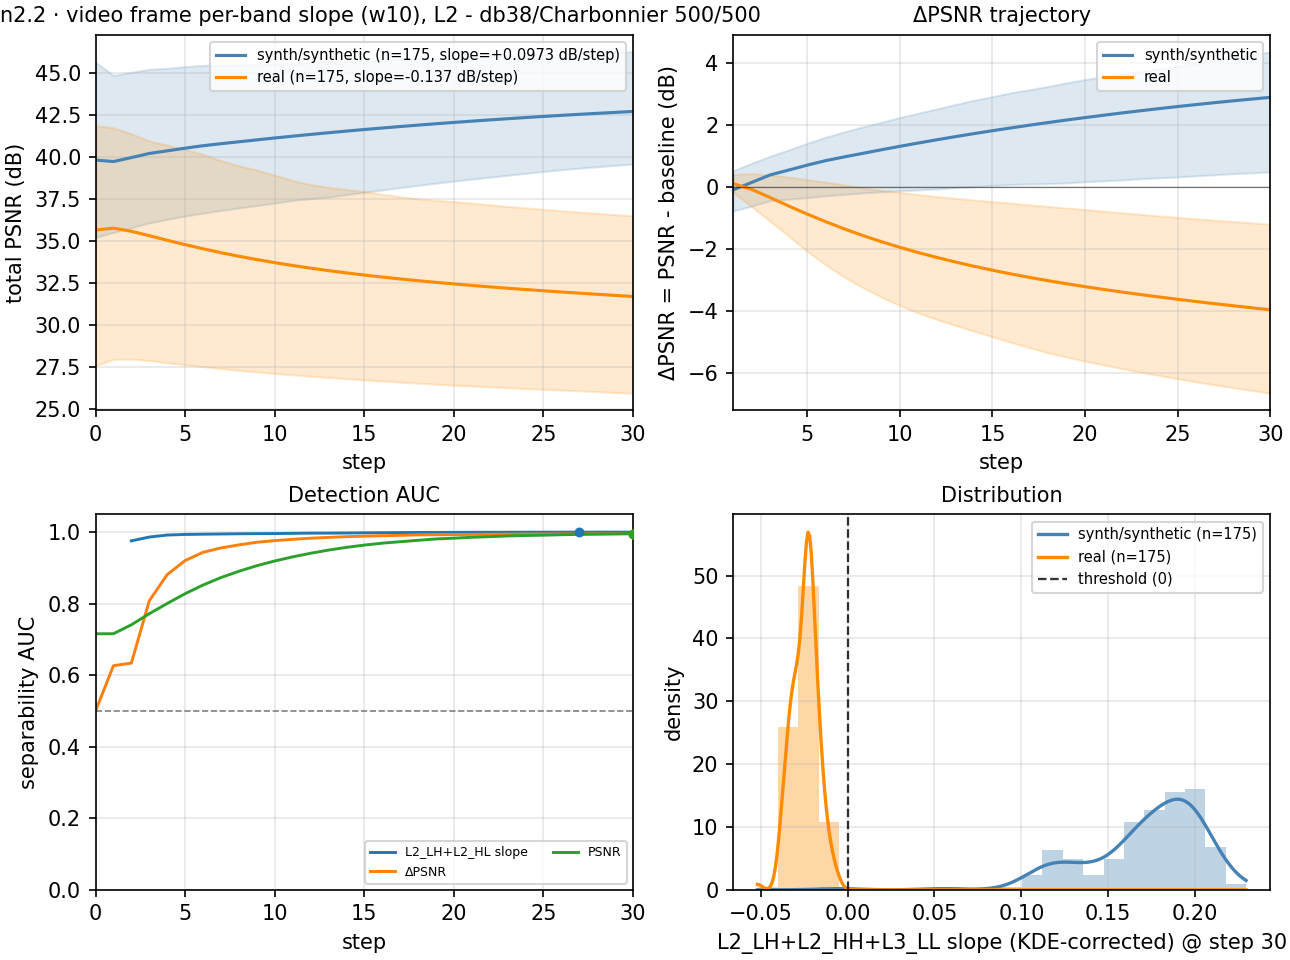

In [50]:
from IPython.display import display
from PIL import Image

display(Image.open(f"results/{slug}_plot.png"))
